**Imports**

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

**Load training data**

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(-1, 784).astype("float32") / 255.0
X_test  = X_test.reshape(-1, 784).astype("float32") / 255.0

In [ ]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(60000, 784) (60000,)
(10000, 784) (10000,)


**Visualize some digits**

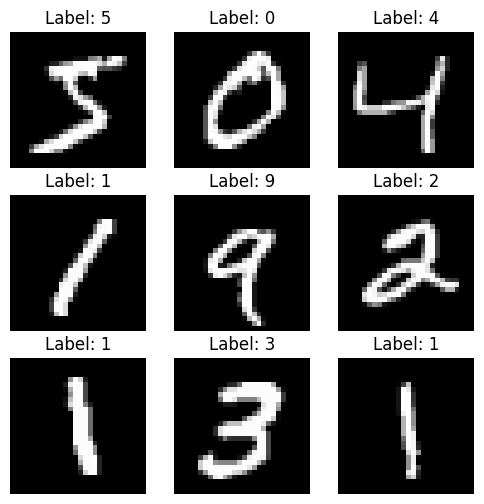

In [ ]:
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

**ANN model**

In [ ]:
model = models.Sequential([
    layers.Input(shape=(784,)),   # 28*28
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

**Train model**

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    verbose=2
)

Epoch 1/20
469/469 - 6s - 12ms/step - accuracy: 0.9228 - loss: 0.2580 - val_accuracy: 0.9826 - val_loss: 0.0664
Epoch 2/20
469/469 - 1s - 2ms/step - accuracy: 0.9709 - loss: 0.0950 - val_accuracy: 0.9797 - val_loss: 0.0392
Epoch 3/20
469/469 - 1s - 2ms/step - accuracy: 0.9797 - loss: 0.0655 - val_accuracy: 0.9942 - val_loss: 0.0257
Epoch 4/20
469/469 - 1s - 3ms/step - accuracy: 0.9851 - loss: 0.0478 - val_accuracy: 0.9971 - val_loss: 0.0111
Epoch 5/20
469/469 - 1s - 2ms/step - accuracy: 0.9879 - loss: 0.0374 - val_accuracy: 0.9913 - val_loss: 0.0205
Epoch 6/20
469/469 - 1s - 2ms/step - accuracy: 0.9910 - loss: 0.0292 - val_accuracy: 0.9971 - val_loss: 0.0086
Epoch 7/20
469/469 - 1s - 2ms/step - accuracy: 0.9926 - loss: 0.0241 - val_accuracy: 0.9942 - val_loss: 0.0143
Epoch 8/20
469/469 - 1s - 2ms/step - accuracy: 0.9923 - loss: 0.0244 - val_accuracy: 0.9913 - val_loss: 0.0312
Epoch 9/20
469/469 - 1s - 3ms/step - accuracy: 0.9940 - loss: 0.0192 - val_accuracy: 0.9942 - val_loss: 0.0168


**Predicion**

In [ ]:
stest_df = pd.read_csv("test.csv")
X_test = test_df.values / 255.0

test_predictions = np.argmax(model.predict(X_test), axis=1)

875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


**Evaluate model**

In [ ]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test Accuracy: 0.9832
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.99      0.98       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.98      1028
           8       0.99      0.97      0.98       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

